###  FEMA Cost Recovery Forecast — Exploratory Data Analysis



### STEP 1 - Setup & Imports

In [39]:
# import Libraries

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configuration
warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Define data paths
DATA_RAW = os.path.join("..", "data", "raw")
DATA_PROCESSED = os.path.join("..", "data", "Processed")

os.makedirs(DATA_PROCESSED, exist_ok=True)

### STEP 2 - Loading the Data


In [40]:
# load dataset
declarations = pd.read_csv(os.path.join(DATA_RAW, "declarations.csv"), parse_dates=["declarationDate", "incidentBeginDate", "incidentEndDate"])
disaster_summaries = pd.read_csv(os.path.join(DATA_RAW, "disaster_summaries.csv"))
public_assistance = pd.read_csv(os.path.join(DATA_RAW, "public_assistance.csv"))

In [41]:
# STEP 2a - Data Overview

for name, df in [
    ("declarations", declarations),
    ("public_assistance", public_assistance),
    ("disaster_summaries", disaster_summaries)
]:
    print(f"{name:<22} {df.shape[0]:>8} rows {df.shape[1]:>3} cols")

declarations              69905 rows  10 cols
public_assistance        812867 rows   8 cols
disaster_summaries         3945 rows  11 cols


In [42]:
# STEP 2b - Data Inspection

print(declarations.dtypes)
print(declarations.isnull().sum())
display(declarations.head())

disasterNumber                            int64
state                                    object
declarationType                          object
incidentType                             object
declarationDate             datetime64[ns, UTC]
incidentBeginDate           datetime64[ns, UTC]
incidentEndDate             datetime64[ns, UTC]
fyDeclared                                int64
designatedArea                           object
declarationRequestNumber                  int64
dtype: object
disasterNumber                0
state                         0
declarationType               0
incidentType                  0
declarationDate               0
incidentBeginDate             0
incidentEndDate             534
fyDeclared                    0
designatedArea                0
declarationRequestNumber      0
dtype: int64


,disasterNumber,state,declarationType,incidentType,declarationDate,incidentBeginDate,incidentEndDate,fyDeclared,designatedArea,declarationRequestNumber
0,3610,PR,EM,Severe Storm,2024-08-13 00:00:00+00:00,2024-08-13 00:00:00+00:00,2024-08-16 00:00:00+00:00,2024,Adjuntas (Municipio),24124
1,5529,OR,FM,Fire,2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaT,2024,Washington (County),24122
2,5528,OR,FM,Fire,2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaT,2024,Jefferson (County),24116
3,5527,OR,FM,Fire,2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaT,2024,Deschutes (County),24111
4,3610,PR,EM,Severe Storm,2024-08-13 00:00:00+00:00,2024-08-13 00:00:00+00:00,2024-08-16 00:00:00+00:00,2024,Aguada (Municipio),24124


### STEP 3 - Convert Date Columns


In [43]:
#  date columns
declaration_date_cols = [
    "declarationDate",
    "incidentBeginDate",
    "incidentEndDate"
    
]

for col in declaration_date_cols:
    if col in declarations.columns:
        declarations[col] = pd.to_datetime(declarations[col], errors="coerce")

  ### STEP 4 - Visualization of the declarartion dataset( declaration distribution)


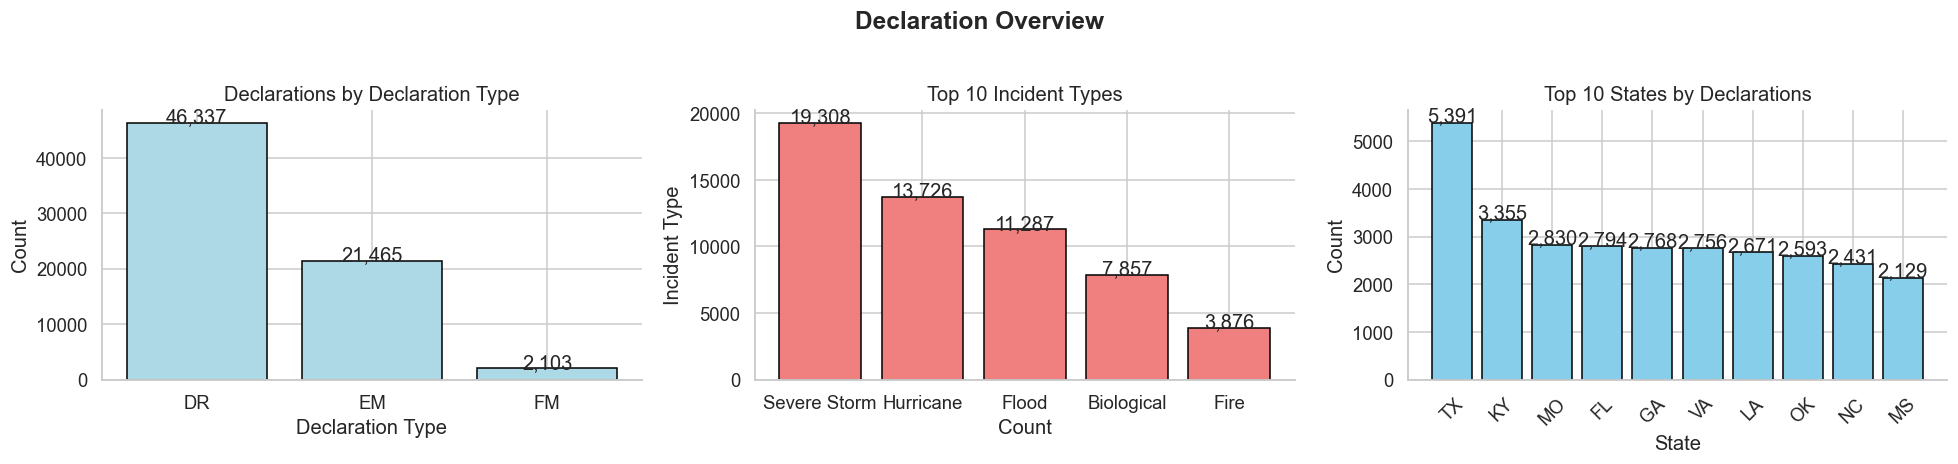

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# step 4a - Declaration type count
if "declarationType" in declarations.columns:
    declaration_type_counts = declarations["declarationType"].value_counts()
    
    # step 4b - plot the distribution
    axes[0].bar(declaration_type_counts.index, declaration_type_counts.values, color="lightblue", edgecolor="black")
    
    # step 4c - configure the plot
    for  i,v, in enumerate (declaration_type_counts.values):
        axes[0].text(i,v + 30, f"{v:,}", ha="center")
    axes[0].set(title="Declarations by Declaration Type", xlabel="Declaration Type", ylabel="Count")

# step 4d- Top incident distribution
if "incidentType" in declarations.columns:
    incident_counts = declarations["incidentType"].value_counts().head()
    axes[1].bar(incident_counts.index, incident_counts.values,color="lightcoral", edgecolor="black")
    
    # configure plot
    for i, v in enumerate(incident_counts.values):
        axes[1].text(i,v + 30, f"{v:,}", ha ="center")
    
    axes[1].set(title="Top 10 Incident Types", xlabel="Count", ylabel="Incident Type")
    #axes[1].invert_yaxis()

# step 4e- Top states distribution
if "state" in declarations.columns:
    state_counts = declarations["state"].value_counts().head(10)
    axes[2].bar(state_counts.index, state_counts.values, color="skyblue",edgecolor="black")
    
    # configure plot
    for i, v in enumerate(state_counts.values):
        axes[2].text(i,v + 30, f"{v:,}", ha = "center")
    
    axes[2].set(title="Top 10 States by Declarations", xlabel="State", ylabel="Count")

plt.suptitle("Declaration Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

### STEP 5a - Declaration Trends Over Time

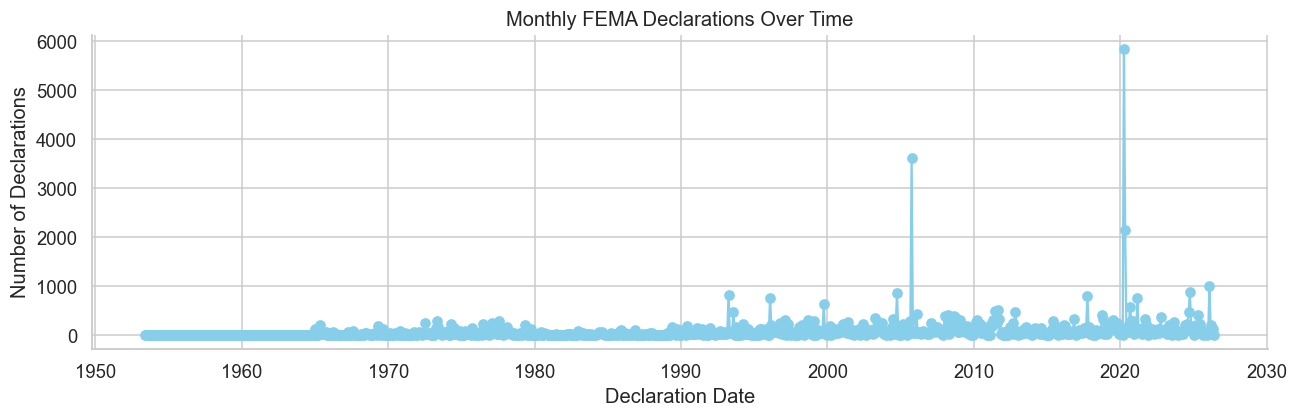

In [45]:
if "declarationDate" in declarations.columns:
    monthly_declarations = (
        declarations
        .set_index("declarationDate")
        .resample("ME")
        .size()
        .reset_index(name="declarations")
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly_declarations["declarationDate"], monthly_declarations["declarations"], marker="o", color="skyblue")
    ax.set(
        title="Monthly FEMA Declarations Over Time",
        xlabel="Declaration Date",
        ylabel="Number of Declarations"
    )

    plt.tight_layout()
    plt.show()

### STEP 5b - Engineer declaration features


In [46]:
 # step 5b(i) Create Duration days:
#  how long disaster last

# example: 

# incident Begin : 2023-08-01
# incident End:    2023-08-15

# Duration = 14 days          

if {"incidentBeginDate", "incidentEndDate"}.issubset(declarations.columns):
    declarations["incident_duration_days"] = (
        declarations["incidentEndDate"] - declarations["incidentBeginDate"]
    ).dt.days
 
# step 5b(ii) create declaration Day
# how long dif Fema take to officially declare the disaster after it started

# Example:

# incident Begin : 2023-08-01
# Declaration date   : 2023-08-10

# delay = 9 days


if {"declarationDate", "incidentBeginDate"}.issubset(declarations.columns):
    declarations["declaration_delay_days"] = (
        declarations["declarationDate"] - declarations["incidentBeginDate"]
    ).dt.days

# step 5b (iii) - descriptive summary

temporal_cols = [
    "incident_duration_days",
    "declaration_delay_days"
]

for col in temporal_cols:
    print(f"{col} summary:")
    print(declarations[col].describe())
    print("declarations[col].skew():", declarations[col].skew())




incident_duration_days summary:
count    69371.000000
mean       156.364965
std        377.290330
min         -7.000000
25%          3.000000
50%         13.000000
75%         39.000000
max       5117.000000
Name: incident_duration_days, dtype: float64
declarations[col].skew(): 2.4334710962673447
declaration_delay_days summary:
count    69905.000000
mean        25.479022
std         32.336160
min       -266.000000
25%          2.000000
50%         11.000000
75%         48.000000
max       2671.000000
Name: declaration_delay_days, dtype: float64
declarations[col].skew(): 9.41174960293306


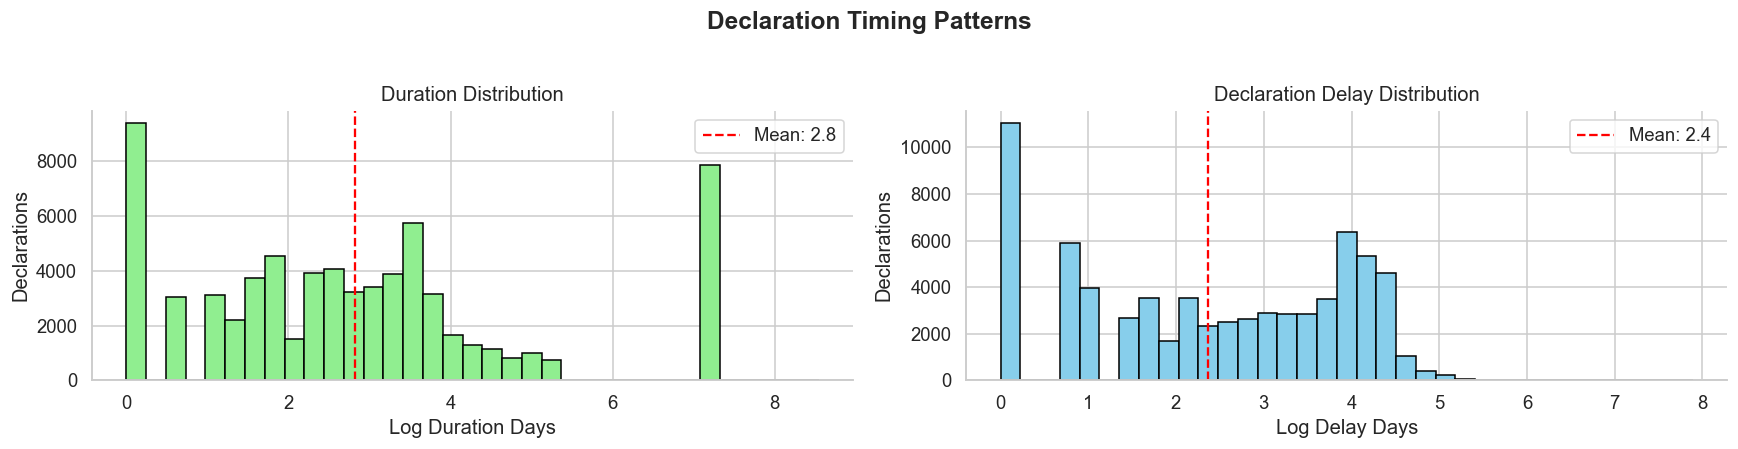

In [47]:

# step 5b (iv) Remove impossible negative values
declarations["incident_duration_days"] = declarations["incident_duration_days"].clip(lower=0)
declarations["declaration_delay_days"] = declarations["declaration_delay_days"].clip(lower=0)

# step 5b(v) Safe log transform
declarations["log_incident_duration_days"] = np.log1p(declarations["incident_duration_days"])
declarations["log_declaration_delay_days"] = np.log1p(declarations["declaration_delay_days"])

# step 5b(vi) Plot both
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# step 5b(vii) - Duration plot
data1 = declarations["log_incident_duration_days"].dropna()
axes[0].hist(data1, bins=35, color="lightgreen", edgecolor="black")
axes[0].axvline(data1.mean(), color="red", linestyle="dashed", label=f"Mean: {data1.mean():.1f}")
axes[0].set(title="Duration Distribution", xlabel="Log Duration Days", ylabel="Declarations")
axes[0].legend()

# step 5b(vii) - Delay plot
data2 = declarations["log_declaration_delay_days"].dropna()
axes[1].hist(data2, bins=35,color="skyblue",edgecolor="black")
axes[1].axvline(data2.mean(), color="red", linestyle="dashed", label=f"Mean: {data2.mean():.1f}")
axes[1].set(title="Declaration Delay Distribution", xlabel="Log Delay Days", ylabel="Declarations")
axes[1].legend()

plt.suptitle("Declaration Timing Patterns", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 6 - Public Assistance Analysis

In [48]:
public_assistance.head()
print(f"Shape: {public_assistance.shape}")
print(public_assistance.dtypes)
print(public_assistance.isnull().sum())

Shape: (812867, 8)
disasterNumber             int64
stateAbbreviation         object
projectAmount            float64
federalShareObligated    float64
totalObligated           float64
projectSize               object
damageCategoryCode        object
applicationTitle          object
dtype: object
disasterNumber           0
stateAbbreviation        0
projectAmount            0
federalShareObligated    0
totalObligated           0
projectSize              0
damageCategoryCode       0
applicationTitle         0
dtype: int64


Step 6a - public Financial Distribution

- 1 - ProjectAmount
- 2 - federalSharedObligated

In [49]:
# check Descriptive summary
financial_cols = [
    "projectAmount",
    "totalObligated",
    "federalShareObligated"
]

for col in financial_cols:

    print(f"{col} summary:")
    print(public_assistance[col].describe().T)
    print("public_assistance[col].skew:", public_assistance[col].skew())

projectAmount summary:


count    8.128670e+05
mean     3.744829e+05
std      1.384843e+07
min     -3.726871e+08
25%      4.410000e+03
50%      1.332490e+04
75%      4.785863e+04
max      8.156162e+09
Name: projectAmount, dtype: float64
public_assistance[col].skew: 309.98788240183103
totalObligated summary:
count    8.128670e+05
mean     3.488927e+05
std      1.348428e+07
min     -3.764233e+08
25%      3.561990e+03
50%      1.082521e+04
75%      3.927941e+04
max      8.156162e+09
Name: totalObligated, dtype: float64
public_assistance[col].skew: 325.09925432743324
federalShareObligated summary:
count    8.128670e+05
mean     3.482599e+05
std      1.347969e+07
min     -3.726871e+08
25%      3.502495e+03
50%      1.067475e+04
75%      3.883789e+04
max      8.156162e+09
Name: federalShareObligated, dtype: float64
public_assistance[col].skew: 325.3526520714994


In [50]:
financial_cols = [
    "totalObligated",
    "federalShareObligated",
    "projectAmount"
]

for col in financial_cols:
    public_assistance[f"log_{col}"] = np.log1p(public_assistance[col])

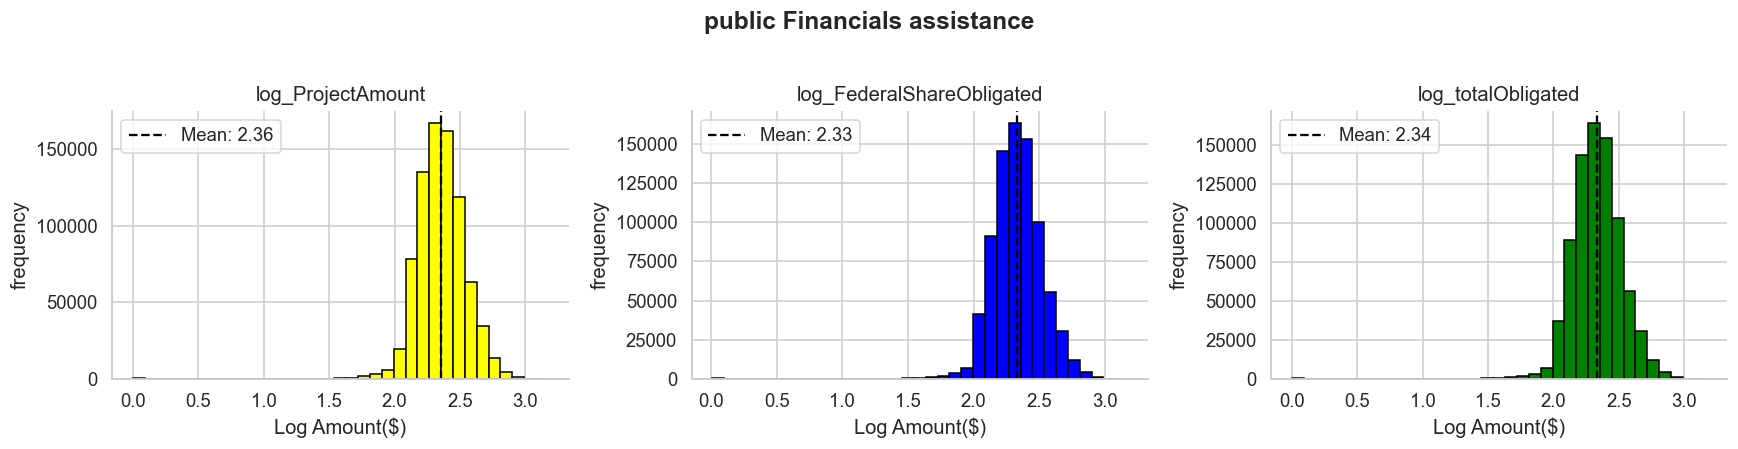

In [51]:
# STEP 6c - Public Assistance Funding Distribution

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, color in zip(
    axes,
    ["log_projectAmount", "log_federalShareObligated", "log_totalObligated"],
    ["log_ProjectAmount", "log_FederalShareObligated", "log_totalObligated"], 
    ["yellow", "blue", "green"]
    ):

    # step 6c(i) filter out negative valuues
    data = public_assistance.loc[
        public_assistance[col]>=0,
        col
    ]

    # step 6c(ii)   log transform
    data = np.log1p(data)

    # step 6c(iii)  plot the distribution
    
    ax.hist(data, bins=35, color=color, edgecolor="black")
    ax.axvline(
        data.mean(), color="black", linestyle="dashed",
        label=f"Mean: {data.mean():.2f}"
    )
    ax.set(title=title, xlabel="Log Amount($)", ylabel="frequency")
    ax.legend()

plt.suptitle("public Financials assistance", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

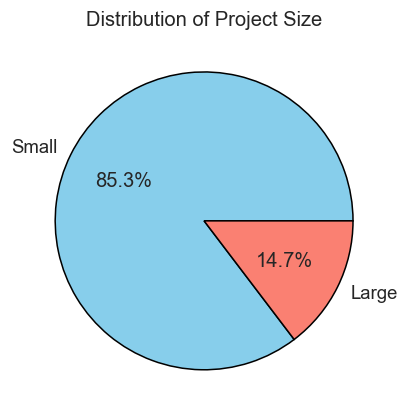

In [52]:
# STEP 6d - Large vs Small Public Assistance Projects
fig, ax = plt.subplots(figsize=(6, 4))

projectSize_counts = public_assistance["projectSize"].value_counts()

ax.pie(
    projectSize_counts.values,
    labels=projectSize_counts.index,
    autopct="%1.1f%%",
    colors=["skyblue", "salmon"],
    wedgeprops={"edgecolor": "black"}
)

ax.set_title("Distribution of Project Size")
plt.tight_layout()
plt.show()

### STEP 7 - Disaster Summaries Dataset Analysis

In [53]:


disaster_summaries.head()
print(f"Shape: {disaster_summaries.shape}")
print(disaster_summaries.dtypes)
print(disaster_summaries.isnull().sum())

Shape: (3945, 11)
disasterNumber                  int64
totalNumberIaApproved         float64
totalAmountIhpApproved        float64
totalAmountHaApproved         float64
totalAmountOnaApproved        float64
totalObligatedAmountPa        float64
totalObligatedAmountCatAb     float64
totalObligatedAmountCatC2g    float64
totalObligatedAmountHmgp      float64
paLoadDate                     object
iaLoadDate                     object
dtype: object
disasterNumber                   0
totalNumberIaApproved         3339
totalAmountIhpApproved        3339
totalAmountHaApproved         3395
totalAmountOnaApproved        3341
totalObligatedAmountPa         956
totalObligatedAmountCatAb     1217
totalObligatedAmountCatC2g    2389
totalObligatedAmountHmgp      1102
paLoadDate                     956
iaLoadDate                    3339
dtype: int64


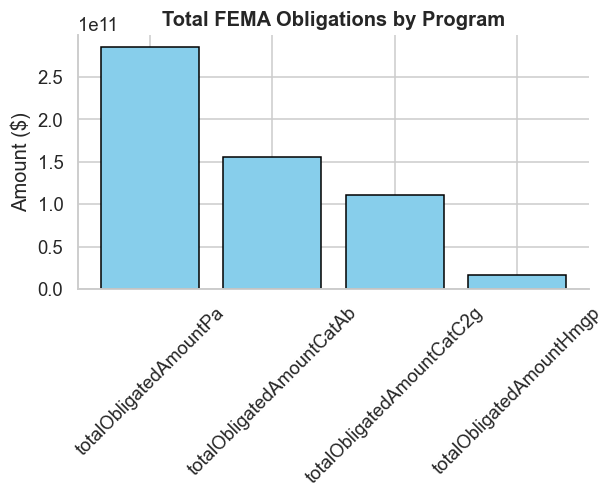

In [54]:
# STEP 7a - Disaster Summary totaloblgated Amounts 

summary_cols = [
    "totalObligatedAmountPa",
    "totalObligatedAmountCatAb",
    "totalObligatedAmountCatC2g",
    "totalObligatedAmountHmgp"
]


program_totals = disaster_summaries[
    summary_cols
].sum()

plt.figure(figsize=(6,3))

plt.bar(
    program_totals.index,
    program_totals.values,
    color="skyblue",
    edgecolor="black"
)

plt.title(
    "Total FEMA Obligations by Program",
    fontweight="bold"
)

plt.ylabel("Amount ($)")
plt.xticks(rotation=45)

plt.show()

### STEP 8 - Bivariate Analysis

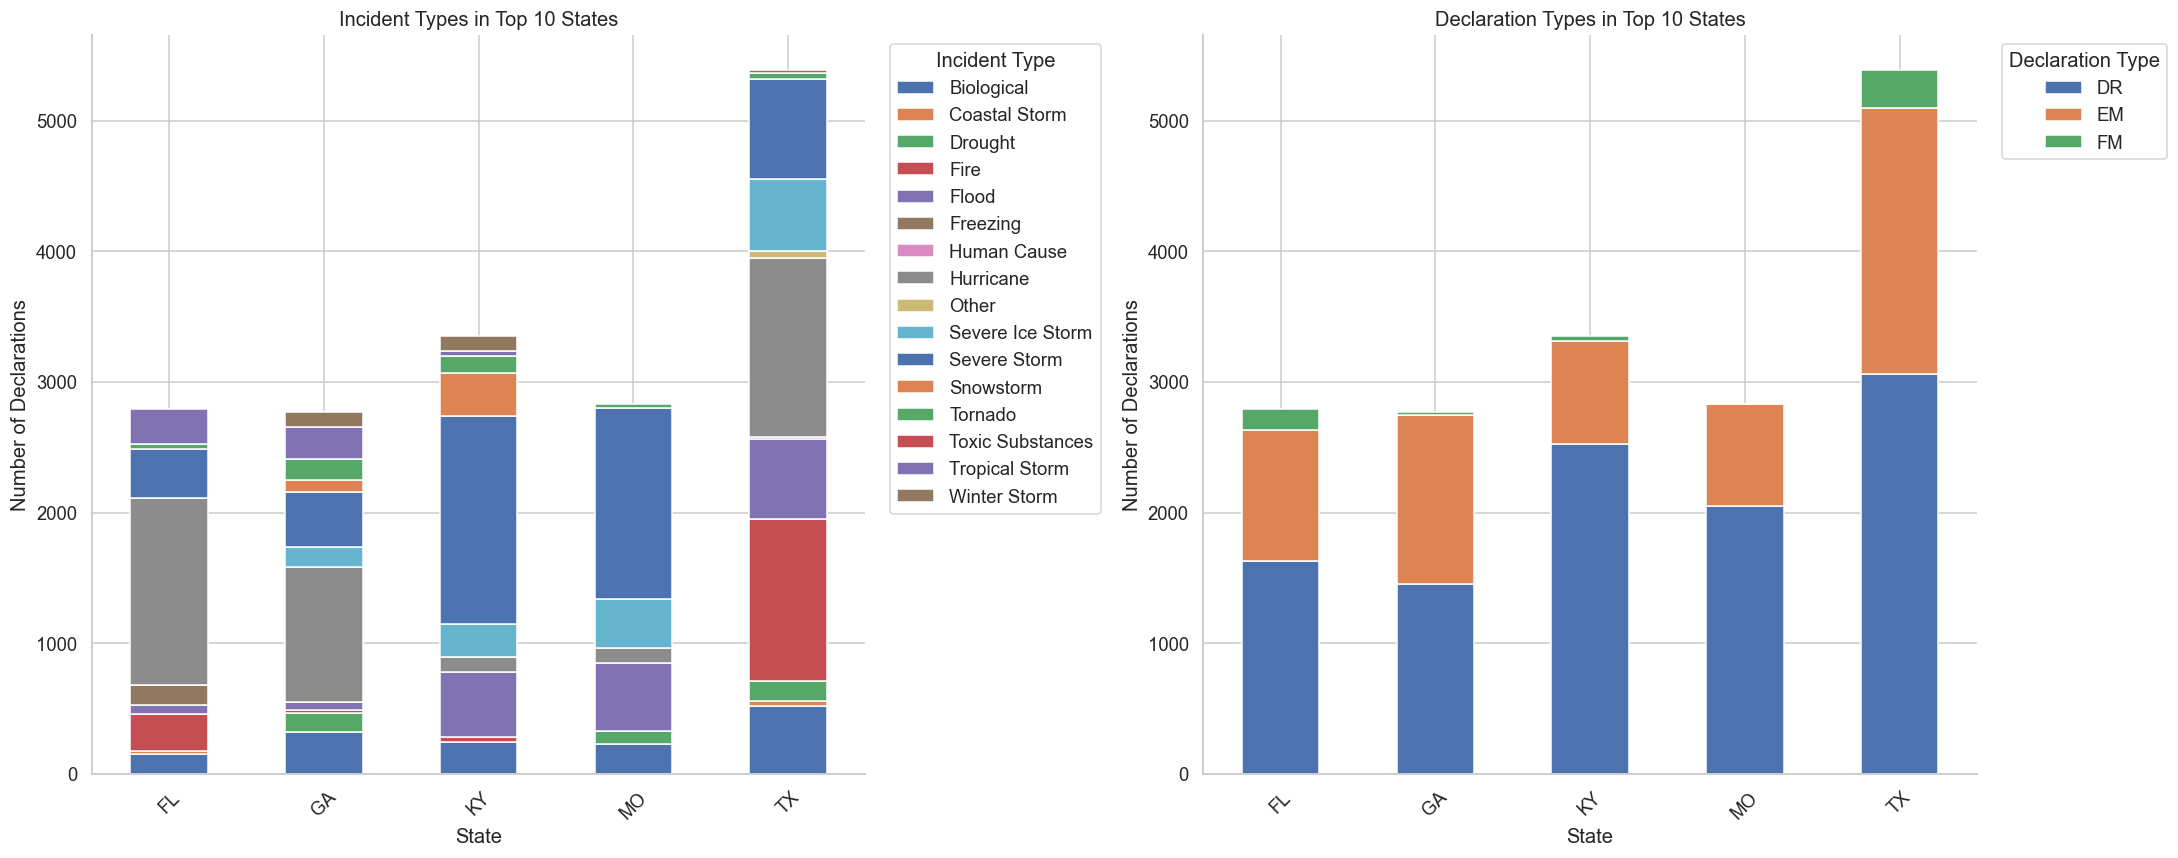

In [ ]:
# step 8a - Top 5 states by number of declarations
top_states = (
    declarations["state"]
    .value_counts()
    .head(5)
    .index
)

# Filter dataset
decl_top = declarations[
    declarations["state"].isin(top_states)
]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Incident Type × State
incident_state = (
    decl_top
    .groupby(["state", "incidentType"])
    .size()
    .unstack(fill_value=0)
)

incident_state.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Incident Types in Top 10 States")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Number of Declarations")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(
    title="Incident Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Declaration Type × State
declaration_state = (
    decl_top
    .groupby(["state", "declarationType"])
    .size()
    .unstack(fill_value=0)
)

declaration_state.plot(
    kind="bar",
    stacked=True,
    ax=axes[1]
)

axes[1].set_title("Declaration Types in Top 10 States")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Number of Declarations")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(
    title="Declaration Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# step 8b - step  incident and declaration analysis

# Which incident types most often result in Major Disaster declarations?
# Which incident types frequently receive Emergency declarations?

incident_declaration = pd.pivot_table(
    declarations,
    index="incidentType",
    columns="declarationType",
    values="disasterNumber",
    aggfunc="count",
    fill_value=0
)

incident_declaration

declarationType,DR,EM,FM
incidentType,,,
Biological,4165,3692,0
Chemical,0,10,0
Coastal Storm,177,460,0
Dam/Levee Break,8,5,0
Drought,87,1205,0
Earthquake,145,83,0
Fire,1067,706,2103
Fishing Losses,34,8,0
Flood,10761,526,0


### STEP 9 - Cross Dataset Summary


In [57]:

print("FEMA EDA Summary")
print("-" * 50)

if "state" in declarations.columns:
    print(f"Top declaration state: {declarations['state'].value_counts().idxmax()}")

if "incidentType" in declarations.columns:
    print(f"Most common incident type: {declarations['incidentType'].value_counts().idxmax()}")

if "declarationType" in declarations.columns:
    print(f"Most common declaration type: {declarations['declarationType'].value_counts().idxmax()}")

if "projectAmount" in public_assistance.columns:
    print(f"Average PA project amount: ${public_assistance['projectAmount'].mean():,.2f}")

if "totalObligated" in public_assistance.columns:
    print(f"Average total obligated amount: ${public_assistance['totalObligated'].mean():,.2f}")

if "totalObligatedAmountPa" in disaster_summaries.columns:
    print(f"Average PA obligated amount from summaries: ${disaster_summaries['totalObligatedAmountPa'].mean():,.2f}")

FEMA EDA Summary
--------------------------------------------------
Top declaration state: TX
Most common incident type: Severe Storm
Most common declaration type: DR
Average PA project amount: $374,482.93
Average total obligated amount: $348,892.66
Average PA obligated amount from summaries: $95,454,461.41
